# 🔗 Notebook 03 — Data Integration & Enrichment

**Project:** FinPulse — Gold & Silver Trading Intelligence Pipeline  
**Phase:** Data Integration, Enrichment, Storage (MongoDB + Neo4j)  
**FAQ Reference:**
- **FAQ 7** — Integrate/enrich at least 2 datasets, automate integration, measure errors
- **FAQ 6** — Model and store in one or more DBMS, at least 2 queries
- **FAQ 9** — Evaluate quality before and after integration

---

## Architecture Overview

```
┌──────────────────────────────────────────────────────────────────┐
│                    INTEGRATION PIPELINE                         │
│                                                                  │
│  ┌─────────────┐    ┌──────────────┐    ┌─────────────────────┐ │
│  │ MongoDB      │    │ Cleaning &   │    │ Enrichment          │ │
│  │ prices (raw) │───▶│ Schema       │───▶│ • Sentiment (VADER) │ │
│  │ news (raw)   │    │ Alignment    │    │ • Technical Indic.  │ │
│  └─────────────┘    └──────────────┘    │ • Daily Aggregation │ │
│                                          └─────────┬───────────┘ │
│                                                    │             │
│                              ┌─────────────────────┼──────────┐  │
│                              │   Temporal Join      │          │  │
│                              │   (date-based)       ▼          │  │
│                              │            ┌─────────────────┐  │  │
│                              │            │ integrated_data │  │  │
│                              └────────────┴─────────────────┘  │  │
│                                          │          │          │  │
│                                    ┌─────┘          └─────┐    │  │
│                                    ▼                      ▼    │  │
│                              ┌──────────┐          ┌────────┐  │  │
│                              │ MongoDB  │          │ Neo4j  │  │  │
│                              │ (document)│          │ (graph)│  │  │
│                              └──────────┘          └────────┘  │  │
└──────────────────────────────────────────────────────────────────┘
```

---

## 1. Setup & Configuration

In [28]:
%pip install py2neo vaderSentiment textblob

Note: you may need to restart the kernel to use updated packages.


In [29]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
from pymongo import MongoClient
from datetime import datetime, timedelta
import re
import warnings
warnings.filterwarnings('ignore')

# Sentiment Analysis
from textblob import TextBlob
# If VADER is available, we use it as primary (more suited for financial text)
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    vader_analyzer = SentimentIntensityAnalyzer()
    USE_VADER = True
    print('✅ VADER sentiment analyzer loaded (primary)')
except ImportError:
    USE_VADER = False
    print('⚠️  VADER not available, using TextBlob as fallback')
    print('   Install with: pip install vaderSentiment')

# Neo4j
try:
    from py2neo import Graph, Node, Relationship, Subgraph
    NEO4J_AVAILABLE = True
    print('✅ py2neo loaded for Neo4j integration')
except ImportError:
    try:
        from neo4j import GraphDatabase
        NEO4J_AVAILABLE = True
        print('✅ neo4j driver loaded for Neo4j integration')
    except ImportError:
        NEO4J_AVAILABLE = False
        print('⚠️  No Neo4j driver available. Install: pip install py2neo')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

import os
os.makedirs('data/exports', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print('\n✅ All libraries imported')

✅ VADER sentiment analyzer loaded (primary)
✅ py2neo loaded for Neo4j integration

✅ All libraries imported


In [30]:
# ============================================================
# DATABASE CONNECTIONS (Docker service names)
# ============================================================

# MongoDB
MONGO_URI = 'mongodb://mongo:27017'   # Docker service name
DB_NAME = 'finpulse'
client = MongoClient(MONGO_URI)
db = client[DB_NAME]

print(f'📦 MongoDB connected — Database: {DB_NAME}')
for coll in ['prices', 'news']:
    print(f'   → {coll}: {db[coll].count_documents({}):,} documents')

# Neo4j
NEO4J_URI = 'bolt://neo4j:7687'       # Docker service name
NEO4J_USER = 'neo4j'
NEO4J_PASS = 'password'

if NEO4J_AVAILABLE:
    try:
        neo4j_graph = Graph(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
        neo4j_graph.run('RETURN 1')  # Test connection
        print(f'📊 Neo4j connected — {NEO4J_URI}')
    except Exception as e:
        print(f'⚠️  Neo4j connection failed: {e}')
        print('   Continuing without Neo4j — will store in MongoDB only')
        NEO4J_AVAILABLE = False

📦 MongoDB connected — Database: finpulse
   → prices: 2,014 documents
   → news: 156 documents
📊 Neo4j connected — bolt://neo4j:7687


---

## 2. Load Raw Data from MongoDB

In [31]:
# ============================================================
# LOAD RAW DATASETS
# ============================================================

# --- Prices ---
df_prices = pd.DataFrame(list(db['prices'].find({}, {'_id': 0})))
df_prices['date'] = pd.to_datetime(df_prices['date'])

# --- News ---
df_news = pd.DataFrame(list(db['news'].find({}, {'_id': 0})))
for col in ['scraped_at', 'published']:
    if col in df_news.columns:
        df_news[col] = pd.to_datetime(df_news[col], errors='coerce')

print('RAW DATA LOADED')
print('=' * 60)
print(f'📈 Prices: {df_prices.shape[0]} rows × {df_prices.shape[1]} cols')
print(f'   Assets: {df_prices["asset_name"].unique().tolist()}')
print(f'   Date range: {df_prices["date"].min().date()} → {df_prices["date"].max().date()}')
print(f'\n📰 News: {df_news.shape[0]} rows × {df_news.shape[1]} cols')
print(f'   Sources: {df_news["source"].unique().tolist() if "source" in df_news.columns else "N/A"}')

RAW DATA LOADED
📈 Prices: 2014 rows × 9 cols
   Assets: ['gold', 'silver', 'dxy', 'sp500']
   Date range: 2024-03-27 → 2026-03-27

📰 News: 156 rows × 6 cols
   Sources: ['CBS News', 'MoneyWeek', 'The Globe and Mail', 'The Conversation', 'AASTOCKS.com', 'thestreet.com', "Barron's", 'J.P. Morgan', 'Reuters', 'Business Standard', 'tradingview.com', 'Yahoo Finance UK', 'Business Insider', 'The Economic Times', 'World Bank Blogs', 'Investing.com', 'KITCO', 'The Gila Herald', 'Invezz', 'VanEck', 'GoldSilver', 'ig.com', 'Citigroup', 'TD Securities', 'CNBC', 'home.saxo', 'ING THINK economic and financial analysis | ING THINK', 'Mining.com', 'facebook.com', 'World Gold Council', 'Forbes India', 'Yahoo Finance Singapore', 'J.P. Morgan Private Bank', 'Apa.az', 'Yahoo Finance', 'Markets.com', 'Goldman Sachs', 'AD HOC NEWS', 'AFR', 'USFunds', 'invesco.com', 'Mint', 'Fortune', 'Yardeni QuickTakes', 'The Times of India', 'thehindu.com', 'TD Economics', 'Capital Economics', 'TradingView', 'economictim

---

## 3. Schema Alignment Analysis

Before integration, we analyze the schema differences between the two datasets  
to design the correct transformation workflow (as per Lecture 4 methodology).

In [32]:
# ============================================================
# SCHEMA COMPARISON — PRICES vs NEWS
# ============================================================

print('SCHEMA ALIGNMENT ANALYSIS')
print('=' * 60)

print('\n--- PRICES schema ---')
for col in df_prices.columns:
    print(f'  {col:20s}  {str(df_prices[col].dtype):15s}  sample: {df_prices[col].iloc[0]}')

print('\n--- NEWS schema ---')
for col in df_news.columns:
    print(f'  {col:20s}  {str(df_news[col].dtype):15s}  sample: {df_news[col].iloc[0]}')

# Identify common fields
common_cols = set(df_prices.columns) & set(df_news.columns)
prices_only = set(df_prices.columns) - set(df_news.columns)
news_only = set(df_news.columns) - set(df_prices.columns)

print(f'\n🔗 Common fields: {common_cols if common_cols else "NONE"}')
print(f'📈 Prices-only fields: {prices_only}')
print(f'📰 News-only fields: {news_only}')

print('\n📋 Integration Key Analysis:')
print('   No direct foreign key exists between prices and news.')
print('   Integration strategy: TEMPORAL JOIN on date.')
print('   News sentiment will be aggregated daily → joined with')
print('   price candles by matching trading dates.')

SCHEMA ALIGNMENT ANALYSIS

--- PRICES schema ---
  asset_name            str              sample: gold
  ticker                str              sample: GC=F
  date                  datetime64[us]   sample: 2024-03-27 00:00:00
  open                  float64          sample: 2179.39990234375
  high                  float64          sample: 2196.199951171875
  low                   float64          sample: 2172.10009765625
  close                 float64          sample: 2190.60009765625
  volume                int64            sample: 31200
  acquired_at           datetime64[us]   sample: 2026-03-27 16:54:12.390000

--- NEWS schema ---
  title                 str              sample: What is the price of gold today? - CBS News
  url                   str              sample: https://news.google.com/rss/articles/CBMibkFVX3lxTE5tZldOT0lPc1h6N1hVT1Bham1FYVp4MlNYdHp4d0ZuT3duam1IajZmY09EdlNjdVZhZTdJQmNQOVZqa2I3TDVKV1V4X2pXMWFGT0N0VlRMRGhvRXNYVElBRWt0QlBPbS1GaVRMMHhn?oc=5
  source            

---

## 4. Pre-Integration Cleaning

Fix the issues identified in Notebook 02 before integrating.

In [33]:
# ============================================================
# 4.1 CLEAN PRICES
# ============================================================

print('CLEANING — PRICES')
print('=' * 60)
initial_count = len(df_prices)

# (a) Remove exact duplicates on (asset_name, date)
dupes_before = df_prices.duplicated(subset=['asset_name', 'date'], keep='first').sum()
df_prices = df_prices.drop_duplicates(subset=['asset_name', 'date'], keep='first')
print(f'  Duplicates removed: {dupes_before}')

# (b) Drop rows where OHLC are all null
ohlc_cols = [c for c in ['open', 'high', 'low', 'close'] if c in df_prices.columns]
null_ohlc = df_prices[ohlc_cols].isnull().all(axis=1).sum()
df_prices = df_prices.dropna(subset=ohlc_cols, how='all')
print(f'  Rows with all-null OHLC removed: {null_ohlc}')

# (c) Forward-fill isolated NaN values in numeric columns
#     (single missing days, common in financial data)
for asset in df_prices['asset_name'].unique():
    mask = df_prices['asset_name'] == asset
    for col in ohlc_cols + ['volume']:
        if col in df_prices.columns:
            nulls_before = df_prices.loc[mask, col].isnull().sum()
            df_prices.loc[mask, col] = df_prices.loc[mask, col].ffill()
            nulls_after = df_prices.loc[mask, col].isnull().sum()
            if nulls_before > nulls_after:
                print(f'  {asset}/{col}: forward-filled {nulls_before - nulls_after} nulls')

# (d) Ensure correct data types
for col in ohlc_cols + (['volume'] if 'volume' in df_prices.columns else []):
    df_prices[col] = pd.to_numeric(df_prices[col], errors='coerce')

# (e) Sort by asset and date
df_prices = df_prices.sort_values(['asset_name', 'date']).reset_index(drop=True)

print(f'\n  Records: {initial_count} → {len(df_prices)} (removed {initial_count - len(df_prices)})')

CLEANING — PRICES
  Duplicates removed: 0
  Rows with all-null OHLC removed: 0

  Records: 2014 → 2014 (removed 0)


In [34]:
# ============================================================
# 4.2 CLEAN NEWS
# ============================================================

print('CLEANING — NEWS')
print('=' * 60)
initial_news = len(df_news)

# (a) Remove exact duplicates on (title, source)
if all(c in df_news.columns for c in ['title', 'source']):
    dupes = df_news.duplicated(subset=['title', 'source'], keep='first').sum()
    df_news = df_news.drop_duplicates(subset=['title', 'source'], keep='first')
    print(f'  Duplicates removed (title+source): {dupes}')

# (b) Drop rows with empty or null titles
if 'title' in df_news.columns:
    empty_titles = (df_news['title'].isnull() | (df_news['title'].str.strip() == '')).sum()
    df_news = df_news[df_news['title'].notna() & (df_news['title'].str.strip() != '')]
    print(f'  Empty/null titles removed: {empty_titles}')

# (c) Normalize title text
if 'title' in df_news.columns:
    df_news['title_clean'] = (
        df_news['title']
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)   # collapse whitespace
        .str.replace(r'[^\w\s\-\.\,\!\?\$\%\'\"\(\)]', '', regex=True)  # remove weird chars
    )
    print(f'  Titles normalized (whitespace, special chars)')

# (d) Create a reference date for news
#     Priority: published > scraped_at
if 'published' in df_news.columns:
    df_news['news_date'] = df_news['published'].dt.normalize()
elif 'scraped_at' in df_news.columns:
    df_news['news_date'] = df_news['scraped_at'].dt.normalize()
else:
    # Fallback: use scraped_at if available in any form
    df_news['news_date'] = pd.NaT

# For news without a valid date, use scraped_at as fallback
if 'scraped_at' in df_news.columns:
    null_dates = df_news['news_date'].isnull()
    df_news.loc[null_dates, 'news_date'] = df_news.loc[null_dates, 'scraped_at'].dt.normalize()
    print(f'  Dates backfilled from scraped_at: {null_dates.sum()}')

remaining_null = df_news['news_date'].isnull().sum()
print(f'  News with valid date: {len(df_news) - remaining_null}/{len(df_news)}')

# Sort
df_news = df_news.sort_values('news_date').reset_index(drop=True)

print(f'\n  Records: {initial_news} → {len(df_news)} (removed {initial_news - len(df_news)})')

CLEANING — NEWS
  Duplicates removed (title+source): 0
  Empty/null titles removed: 0
  Titles normalized (whitespace, special chars)
  Dates backfilled from scraped_at: 10
  News with valid date: 156/156

  Records: 156 → 156 (removed 0)


---

## 5. Enrichment Phase 1 — Sentiment Analysis on News

**Enrichment type:** Feature generation via NLP  
**Method:** VADER (primary, tuned for social/financial text) + TextBlob (secondary, for comparison)  
**Output:** Each news headline gets a sentiment score [-1, +1] and a label (positive/negative/neutral)

In [35]:
# ============================================================
# 5.1 SENTIMENT SCORING FUNCTIONS
# ============================================================

def get_vader_sentiment(text):
    """VADER compound score: [-1, +1]"""
    if pd.isna(text) or not text.strip():
        return {'compound': 0.0, 'pos': 0.0, 'neg': 0.0, 'neu': 1.0}
    return vader_analyzer.polarity_scores(text)

def get_textblob_sentiment(text):
    """TextBlob polarity: [-1, +1], subjectivity: [0, 1]"""
    if pd.isna(text) or not text.strip():
        return {'polarity': 0.0, 'subjectivity': 0.0}
    blob = TextBlob(text)
    return {'polarity': blob.sentiment.polarity, 
            'subjectivity': blob.sentiment.subjectivity}

def classify_sentiment(score, thresholds=(-0.05, 0.05)):
    """Classify sentiment score into categorical label."""
    if score <= thresholds[0]:
        return 'negative'
    elif score >= thresholds[1]:
        return 'positive'
    return 'neutral'

print('✅ Sentiment functions defined')

✅ Sentiment functions defined


In [36]:
# ============================================================
# 5.2 APPLY SENTIMENT TO ALL NEWS HEADLINES
# ============================================================

title_col = 'title_clean' if 'title_clean' in df_news.columns else 'title'

print(f'Computing sentiment on {len(df_news)} headlines...')
print(f'Using column: {title_col}')

# --- VADER (primary) ---
if USE_VADER:
    vader_scores = df_news[title_col].apply(get_vader_sentiment)
    df_news['sentiment_vader'] = vader_scores.apply(lambda x: x['compound'])
    df_news['sentiment_vader_pos'] = vader_scores.apply(lambda x: x['pos'])
    df_news['sentiment_vader_neg'] = vader_scores.apply(lambda x: x['neg'])
    df_news['sentiment_label'] = df_news['sentiment_vader'].apply(classify_sentiment)
    primary_col = 'sentiment_vader'
    print(f'  ✅ VADER scores computed')

# --- TextBlob (secondary / comparison) ---
tb_scores = df_news[title_col].apply(get_textblob_sentiment)
df_news['sentiment_textblob'] = tb_scores.apply(lambda x: x['polarity'])
df_news['subjectivity'] = tb_scores.apply(lambda x: x['subjectivity'])
print(f'  ✅ TextBlob scores computed')

if not USE_VADER:
    df_news['sentiment_label'] = df_news['sentiment_textblob'].apply(classify_sentiment)
    primary_col = 'sentiment_textblob'

# --- Summary ---
print(f'\nSENTIMENT DISTRIBUTION:')
print(df_news['sentiment_label'].value_counts().to_string())
print(f'\nSentiment stats ({primary_col}):')
print(df_news[primary_col].describe().round(4).to_string())

Computing sentiment on 156 headlines...
Using column: title_clean
  ✅ VADER scores computed
  ✅ TextBlob scores computed

SENTIMENT DISTRIBUTION:
sentiment_label
neutral     69
negative    44
positive    43

Sentiment stats (sentiment_vader):
count    156.0000
mean      -0.0128
std        0.3344
min       -0.9217
25%       -0.2053
50%        0.0000
75%        0.1027
max        0.8899


ENRICHMENT CROSS-VALIDATION: VADER vs TextBlob
  Pearson correlation: 0.2900
  Polarity direction agreement: 44.9%
  Mean Absolute Difference: 0.2242
  Strong disagreements (opposite polarity): 16 (10.3%)

  Sample disagreements:
    "When Uncertainty Rises, Gold Rallies Precious Metals Surge t..."
      VADER: -0.103  |  TextBlob: +0.250
    "Gold up to $4,400, silver down to mid-$40s, but PGMs will le..."
      VADER: +0.421  |  TextBlob: -0.156
    "Gold among the few commodity opportunities in 2026, price co..."
      VADER: +0.572  |  TextBlob: -0.200
    "Gold price down, silver strongly down amid extreme volatilit..."
      VADER: +0.273  |  TextBlob: -0.145
    "Commodity Radar US-Venezuela tensions lift gold, but charts ..."
      VADER: -0.214  |  TextBlob: +0.200


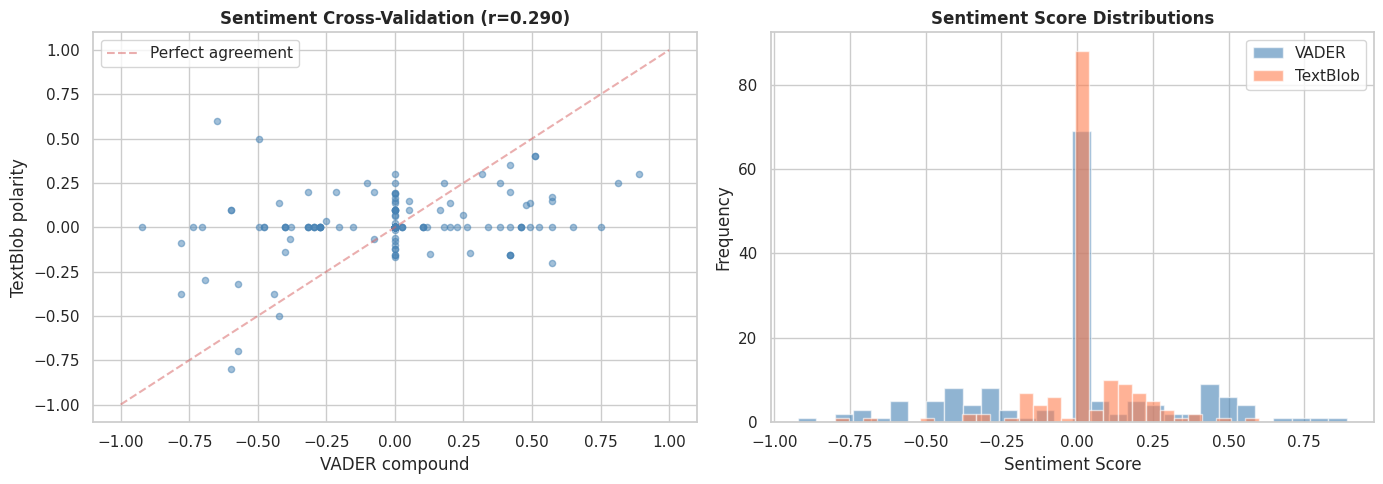

In [37]:
# ============================================================
# 5.3 CROSS-VALIDATE SENTIMENT: VADER vs TEXTBLOB
# This measures agreement between two enrichment methods,
# which is a form of integration error measurement (FAQ 7).
# ============================================================

if USE_VADER:
    print('ENRICHMENT CROSS-VALIDATION: VADER vs TextBlob')
    print('=' * 60)
    
    # Correlation between the two methods
    corr = df_news['sentiment_vader'].corr(df_news['sentiment_textblob'])
    print(f'  Pearson correlation: {corr:.4f}')
    
    # Agreement on polarity direction
    vader_sign = np.sign(df_news['sentiment_vader'])
    tb_sign = np.sign(df_news['sentiment_textblob'])
    agreement = (vader_sign == tb_sign).mean() * 100
    print(f'  Polarity direction agreement: {agreement:.1f}%')
    
    # Mean Absolute Difference (MAD)
    mad = (df_news['sentiment_vader'] - df_news['sentiment_textblob']).abs().mean()
    print(f'  Mean Absolute Difference: {mad:.4f}')
    
    # Disagreement cases (one positive, other negative)
    disagree = ((vader_sign == 1) & (tb_sign == -1)) | ((vader_sign == -1) & (tb_sign == 1))
    print(f'  Strong disagreements (opposite polarity): {disagree.sum()} ({disagree.mean()*100:.1f}%)')
    
    if disagree.sum() > 0:
        print(f'\n  Sample disagreements:')
        samples = df_news[disagree].head(5)
        for _, row in samples.iterrows():
            print(f'    "{row[title_col][:60]}..."')
            print(f'      VADER: {row["sentiment_vader"]:+.3f}  |  TextBlob: {row["sentiment_textblob"]:+.3f}')

    # Scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(df_news['sentiment_vader'], df_news['sentiment_textblob'],
                    alpha=0.5, s=20, color='steelblue')
    axes[0].plot([-1, 1], [-1, 1], 'r--', alpha=0.5, label='Perfect agreement')
    axes[0].set_xlabel('VADER compound')
    axes[0].set_ylabel('TextBlob polarity')
    axes[0].set_title(f'Sentiment Cross-Validation (r={corr:.3f})', fontweight='bold')
    axes[0].legend()
    axes[0].set_xlim(-1.1, 1.1)
    axes[0].set_ylim(-1.1, 1.1)
    
    # Distribution comparison
    axes[1].hist(df_news['sentiment_vader'], bins=30, alpha=0.6, label='VADER', color='steelblue')
    axes[1].hist(df_news['sentiment_textblob'], bins=30, alpha=0.6, label='TextBlob', color='coral')
    axes[1].set_xlabel('Sentiment Score')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Sentiment Score Distributions', fontweight='bold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('data/exports/integration_sentiment_validation.png', dpi=150, bbox_inches='tight')
    plt.show()

---

## 6. Enrichment Phase 2 — Technical Indicators on Prices

We enrich the price data with computed features that are standard in financial analysis.
This is the second enrichment activity for FAQ 7.

In [38]:
# ============================================================
# 6.1 COMPUTE TECHNICAL INDICATORS (per asset)
# ============================================================

def compute_technical_indicators(df, close_col='close', window_short=7, window_long=21):
    """
    Enrich a price DataFrame with technical indicators.
    All computed per-asset, assuming df is sorted by date.
    
    Returns the enriched DataFrame.
    """
    df = df.copy()
    close = df[close_col]
    
    # --- Moving Averages ---
    df['sma_7'] = close.rolling(window=window_short, min_periods=1).mean()
    df['sma_21'] = close.rolling(window=window_long, min_periods=1).mean()
    df['ema_7'] = close.ewm(span=window_short, adjust=False).mean()
    df['ema_21'] = close.ewm(span=window_long, adjust=False).mean()
    
    # --- Daily Returns ---
    df['daily_return'] = close.pct_change()
    df['daily_return_pct'] = df['daily_return'] * 100
    
    # --- Volatility (rolling std of returns) ---
    df['volatility_7'] = df['daily_return'].rolling(window=window_short, min_periods=2).std()
    df['volatility_21'] = df['daily_return'].rolling(window=window_long, min_periods=2).std()
    
    # --- Bollinger Bands (20-day, 2 std) ---
    bb_window = 20
    bb_sma = close.rolling(window=bb_window, min_periods=1).mean()
    bb_std = close.rolling(window=bb_window, min_periods=1).std()
    df['bollinger_upper'] = bb_sma + 2 * bb_std
    df['bollinger_lower'] = bb_sma - 2 * bb_std
    df['bollinger_pct'] = (close - bb_sma) / (2 * bb_std)  # Position within bands [-1, 1]
    
    # --- RSI (Relative Strength Index, 14-period) ---
    delta = close.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = (-delta).where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=14, min_periods=1).mean()
    avg_loss = loss.rolling(window=14, min_periods=1).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    df['rsi_14'] = 100 - (100 / (1 + rs))
    
    # --- Price relative to SMA (signal) ---
    df['price_vs_sma21'] = (close / df['sma_21'] - 1) * 100  # % above/below SMA21
    
    return df


# Apply per asset
print('TECHNICAL INDICATORS ENRICHMENT')
print('=' * 60)

enriched_frames = []
for asset in df_prices['asset_name'].unique():
    df_asset = df_prices[df_prices['asset_name'] == asset].sort_values('date').copy()
    df_enriched = compute_technical_indicators(df_asset)
    enriched_frames.append(df_enriched)
    
    # Report
    new_cols = [c for c in df_enriched.columns if c not in df_prices.columns]
    print(f'  {asset}: +{len(new_cols)} features added ({len(df_asset)} records)')

df_prices_enriched = pd.concat(enriched_frames, ignore_index=True)

print(f'\n📈 Enriched prices: {df_prices_enriched.shape[0]} rows × {df_prices_enriched.shape[1]} cols')
print(f'   New columns: {[c for c in df_prices_enriched.columns if c not in df_prices.columns]}')

TECHNICAL INDICATORS ENRICHMENT
  dxy: +13 features added (504 records)
  gold: +13 features added (504 records)
  silver: +13 features added (504 records)
  sp500: +13 features added (502 records)

📈 Enriched prices: 2014 rows × 22 cols
   New columns: ['sma_7', 'sma_21', 'ema_7', 'ema_21', 'daily_return', 'daily_return_pct', 'volatility_7', 'volatility_21', 'bollinger_upper', 'bollinger_lower', 'bollinger_pct', 'rsi_14', 'price_vs_sma21']


---

## 7. Temporal Integration — Join Prices + Sentiment

This is the core integration step (FAQ 7). We perform a **temporal join**:
1. Aggregate daily news sentiment (mean, count, min, max)
2. Join with price data on **date** (left join from prices)
3. Handle days with no news (fill with neutral sentiment)

### Integration Error Measurement
We measure:
- **Coverage**: % of trading days that have matching news
- **Temporal alignment error**: lag between news date and trading date
- **Unmatched records**: prices without news, news without prices

In [39]:
# ============================================================
# 7.1 AGGREGATE DAILY SENTIMENT
# ============================================================

# Determine primary sentiment column
sent_col = 'sentiment_vader' if 'sentiment_vader' in df_news.columns else 'sentiment_textblob'

# Only aggregate news that have a valid date
df_news_valid = df_news[df_news['news_date'].notna()].copy()

print(f'DAILY SENTIMENT AGGREGATION')
print(f'  Valid news with date: {len(df_news_valid)}/{len(df_news)}')

# Aggregate by date
daily_sentiment = df_news_valid.groupby('news_date').agg(
    sentiment_mean=(sent_col, 'mean'),
    sentiment_median=(sent_col, 'median'),
    sentiment_min=(sent_col, 'min'),
    sentiment_max=(sent_col, 'max'),
    sentiment_std=(sent_col, 'std'),
    news_count=('title', 'count'),
    positive_ratio=('sentiment_label', lambda x: (x == 'positive').mean()),
    negative_ratio=('sentiment_label', lambda x: (x == 'negative').mean()),
).reset_index()

# Fill std NaN (days with single news)
daily_sentiment['sentiment_std'] = daily_sentiment['sentiment_std'].fillna(0)

# Rename date column for join
daily_sentiment = daily_sentiment.rename(columns={'news_date': 'date'})

print(f'  Days with news coverage: {len(daily_sentiment)}')
print(f'  Date range: {daily_sentiment["date"].min().date()} → {daily_sentiment["date"].max().date()}')
print(f'\n  Daily aggregation stats:')
print(daily_sentiment[['sentiment_mean', 'news_count']].describe().round(3).to_string())

DAILY SENTIMENT AGGREGATION
  Valid news with date: 156/156
  Days with news coverage: 82
  Date range: 2025-05-15 → 2026-03-28

  Daily aggregation stats:
       sentiment_mean  news_count
count          82.000      82.000
mean           -0.023       1.902
std             0.291       1.645
min            -0.778       1.000
25%            -0.130       1.000
50%             0.000       1.000
75%             0.114       2.000
max             0.572      10.000


In [40]:
# ============================================================
# 7.2 TEMPORAL JOIN — PRICES + DAILY SENTIMENT
# ============================================================

print('TEMPORAL INTEGRATION')
print('=' * 60)

# Focus on gold (primary asset) for the integrated dataset
# but also create the full integration for all assets

# Normalize dates for joining
df_prices_enriched['date_norm'] = df_prices_enriched['date'].dt.normalize()
daily_sentiment['date_norm'] = daily_sentiment['date'].dt.normalize()

# LEFT JOIN: keep all price records, add sentiment where available
df_integrated = df_prices_enriched.merge(
    daily_sentiment,
    left_on='date_norm',
    right_on='date_norm',
    how='left',
    suffixes=('', '_sentiment')
)

# Drop duplicate date columns from merge
if 'date_sentiment' in df_integrated.columns:
    df_integrated = df_integrated.drop(columns=['date_sentiment'])

print(f'  Integrated dataset: {df_integrated.shape[0]} rows × {df_integrated.shape[1]} cols')

# ============================================================
# 7.3 HANDLE MISSING SENTIMENT (days without news)
# Strategy: fill with neutral values (0.0 sentiment, 0 news)
# ============================================================

sentiment_cols = ['sentiment_mean', 'sentiment_median', 'sentiment_min', 
                  'sentiment_max', 'sentiment_std', 'positive_ratio', 'negative_ratio']

for col in sentiment_cols:
    if col in df_integrated.columns:
        df_integrated[col] = df_integrated[col].fillna(0.0)

if 'news_count' in df_integrated.columns:
    df_integrated['news_count'] = df_integrated['news_count'].fillna(0).astype(int)

# Add a flag for whether the day had real news data
df_integrated['has_news'] = df_integrated['news_count'] > 0

print(f'  Days with news: {df_integrated["has_news"].sum()}')
print(f'  Days without news: {(~df_integrated["has_news"]).sum()}')

TEMPORAL INTEGRATION
  Integrated dataset: 2014 rows × 31 cols
  Days with news: 308
  Days without news: 1706


In [41]:
# ============================================================
# 7.4 INTEGRATION ERROR MEASUREMENT (FAQ 7 — MANDATORY)
# ============================================================

print('\nINTEGRATION ERROR MEASUREMENT')
print('=' * 60)

# --- Error 1: Coverage ---
# What % of trading days have at least one news article?
total_trading_days = df_integrated['date_norm'].nunique()
days_with_news = df_integrated[df_integrated['has_news']]['date_norm'].nunique()
coverage_pct = days_with_news / total_trading_days * 100 if total_trading_days > 0 else 0

print(f'\n📊 Error 1 — Coverage:')
print(f'   Trading days total: {total_trading_days}')
print(f'   Trading days with news: {days_with_news}')
print(f'   Coverage: {coverage_pct:.1f}%')
print(f'   Missing coverage: {100 - coverage_pct:.1f}%')

# --- Error 2: Unmatched records ---
# News that don't match any trading day (weekends, holidays)
trading_dates = set(df_prices_enriched['date_norm'].unique())
news_dates = set(daily_sentiment['date_norm'].unique())

news_no_price = news_dates - trading_dates  # News on non-trading days
price_no_news = trading_dates - news_dates  # Trading days without news

print(f'\n📊 Error 2 — Unmatched records:')
print(f'   News on non-trading days (lost): {len(news_no_price)}')
print(f'   Trading days without any news: {len(price_no_news)}')

# --- Error 3: Temporal granularity mismatch ---
# Prices are daily candles; news timestamps may be intraday
# Error = information loss from aggregating intraday news to daily
if 'news_count' in daily_sentiment.columns:
    multi_news_days = (daily_sentiment['news_count'] > 1).sum()
    max_news_day = daily_sentiment['news_count'].max()
    avg_news = daily_sentiment['news_count'].mean()
    print(f'\n📊 Error 3 — Temporal granularity:')
    print(f'   Days with multiple news items: {multi_news_days}')
    print(f'   Max news in a single day: {max_news_day}')
    print(f'   Avg news per day: {avg_news:.1f}')
    print(f'   Aggregation info loss: intraday sentiment variation → single daily mean')
    if daily_sentiment['sentiment_std'].mean() > 0:
        print(f'   Avg intra-day sentiment std: {daily_sentiment["sentiment_std"].mean():.4f}')

# --- Error 4: Schema integration completeness ---
# How many columns have nulls after integration?
null_pcts = (df_integrated.isnull().sum() / len(df_integrated) * 100)
cols_with_nulls = null_pcts[null_pcts > 0]
print(f'\n📊 Error 4 — Schema completeness after integration:')
if len(cols_with_nulls) > 0:
    print(f'   Columns with remaining nulls:')
    for col, pct in cols_with_nulls.items():
        print(f'     {col}: {pct:.1f}%')
else:
    print(f'   ✅ No null values in integrated dataset')

# --- Store integration metrics ---
integration_errors = {
    'timestamp': datetime.utcnow(),
    'coverage_pct': round(coverage_pct, 2),
    'news_on_non_trading_days': len(news_no_price),
    'trading_days_without_news': len(price_no_news),
    'total_trading_days': total_trading_days,
    'days_with_news': days_with_news,
    'avg_intraday_sentiment_std': round(daily_sentiment['sentiment_std'].mean(), 4),
    'columns_with_nulls': len(cols_with_nulls)
}
db['integration_errors'].insert_one(integration_errors)
print(f'\n💾 Integration error metrics saved to MongoDB: integration_errors')


INTEGRATION ERROR MEASUREMENT

📊 Error 1 — Coverage:
   Trading days total: 505
   Trading days with news: 77
   Coverage: 15.2%
   Missing coverage: 84.8%

📊 Error 2 — Unmatched records:
   News on non-trading days (lost): 5
   Trading days without any news: 428

📊 Error 3 — Temporal granularity:
   Days with multiple news items: 32
   Max news in a single day: 10
   Avg news per day: 1.9
   Aggregation info loss: intraday sentiment variation → single daily mean
   Avg intra-day sentiment std: 0.0793

📊 Error 4 — Schema completeness after integration:
   Columns with remaining nulls:
     daily_return: 0.2%
     daily_return_pct: 0.2%
     volatility_7: 0.4%
     volatility_21: 0.4%
     bollinger_upper: 0.2%
     bollinger_lower: 0.2%
     bollinger_pct: 0.2%
     rsi_14: 1.1%

💾 Integration error metrics saved to MongoDB: integration_errors


---

## 8. Integrated Document Design & Storage in MongoDB

In [42]:
# ============================================================
# 8.1 DESIGN THE INTEGRATED DOCUMENT SCHEMA
# ============================================================

# Show the integrated schema
print('INTEGRATED DOCUMENT SCHEMA')
print('=' * 60)

schema_doc = """
{
    "asset_name": "Gold",
    "ticker": "GC=F",
    "date": ISODate("2024-01-15"),
    
    // --- Price Data (Source 1: Yahoo Finance) ---
    "ohlcv": {
        "open": 2048.50,
        "high": 2062.30,
        "low": 2041.10,
        "close": 2055.70,
        "volume": 185400
    },
    
    // --- Technical Indicators (Enrichment 1) ---
    "technicals": {
        "sma_7": 2050.2,
        "sma_21": 2035.8,
        "ema_7": 2051.1,
        "rsi_14": 58.3,
        "bollinger_upper": 2080.5,
        "bollinger_lower": 2010.2,
        "daily_return_pct": 0.45,
        "volatility_7": 0.012,
        "volatility_21": 0.015
    },
    
    // --- Sentiment Data (Source 2: Reuters/Google News + NLP) ---
    "sentiment": {
        "mean": 0.15,
        "median": 0.12,
        "min": -0.35,
        "max": 0.65,
        "std": 0.18,
        "news_count": 5,
        "positive_ratio": 0.6,
        "negative_ratio": 0.2,
        "has_news": true
    },
    
    // --- Metadata ---
    "integrated_at": ISODate("2025-03-28T10:00:00Z")
}
"""
print(schema_doc)

INTEGRATED DOCUMENT SCHEMA

{
    "asset_name": "Gold",
    "ticker": "GC=F",
    "date": ISODate("2024-01-15"),
    
    // --- Price Data (Source 1: Yahoo Finance) ---
    "ohlcv": {
        "open": 2048.50,
        "high": 2062.30,
        "low": 2041.10,
        "close": 2055.70,
        "volume": 185400
    },
    
    // --- Technical Indicators (Enrichment 1) ---
    "technicals": {
        "sma_7": 2050.2,
        "sma_21": 2035.8,
        "ema_7": 2051.1,
        "rsi_14": 58.3,
        "bollinger_upper": 2080.5,
        "bollinger_lower": 2010.2,
        "daily_return_pct": 0.45,
        "volatility_7": 0.012,
        "volatility_21": 0.015
    },
    
    // --- Sentiment Data (Source 2: Reuters/Google News + NLP) ---
    "sentiment": {
        "mean": 0.15,
        "median": 0.12,
        "min": -0.35,
        "max": 0.65,
        "std": 0.18,
        "news_count": 5,
        "positive_ratio": 0.6,
        "negative_ratio": 0.2,
        "has_news": true
    },
    
    // -

In [43]:
# ============================================================
# 8.2 BUILD AND STORE INTEGRATED DOCUMENTS IN MONGODB
# ============================================================

print('STORING INTEGRATED DATA IN MONGODB')
print('=' * 60)

# Build nested document structure (as per Lecture 4 methodology)
integrated_docs = []

for _, row in df_integrated.iterrows():
    doc = {
        'asset_name': row.get('asset_name'),
        'ticker': row.get('ticker'),
        'date': row.get('date'),
        
        # Nested OHLCV
        'ohlcv': {
            'open': float(row['open']) if pd.notna(row.get('open')) else None,
            'high': float(row['high']) if pd.notna(row.get('high')) else None,
            'low': float(row['low']) if pd.notna(row.get('low')) else None,
            'close': float(row['close']) if pd.notna(row.get('close')) else None,
            'volume': int(row['volume']) if pd.notna(row.get('volume')) else 0,
        },
        
        # Nested technicals
        'technicals': {
            'sma_7': float(row['sma_7']) if pd.notna(row.get('sma_7')) else None,
            'sma_21': float(row['sma_21']) if pd.notna(row.get('sma_21')) else None,
            'ema_7': float(row['ema_7']) if pd.notna(row.get('ema_7')) else None,
            'ema_21': float(row['ema_21']) if pd.notna(row.get('ema_21')) else None,
            'rsi_14': float(row['rsi_14']) if pd.notna(row.get('rsi_14')) else None,
            'bollinger_upper': float(row['bollinger_upper']) if pd.notna(row.get('bollinger_upper')) else None,
            'bollinger_lower': float(row['bollinger_lower']) if pd.notna(row.get('bollinger_lower')) else None,
            'bollinger_pct': float(row['bollinger_pct']) if pd.notna(row.get('bollinger_pct')) else None,
            'daily_return_pct': float(row['daily_return_pct']) if pd.notna(row.get('daily_return_pct')) else None,
            'volatility_7': float(row['volatility_7']) if pd.notna(row.get('volatility_7')) else None,
            'volatility_21': float(row['volatility_21']) if pd.notna(row.get('volatility_21')) else None,
            'price_vs_sma21': float(row['price_vs_sma21']) if pd.notna(row.get('price_vs_sma21')) else None,
        },
        
        # Nested sentiment
        'sentiment': {
            'mean': float(row.get('sentiment_mean', 0)),
            'median': float(row.get('sentiment_median', 0)),
            'min': float(row.get('sentiment_min', 0)),
            'max': float(row.get('sentiment_max', 0)),
            'std': float(row.get('sentiment_std', 0)),
            'news_count': int(row.get('news_count', 0)),
            'positive_ratio': float(row.get('positive_ratio', 0)),
            'negative_ratio': float(row.get('negative_ratio', 0)),
            'has_news': bool(row.get('has_news', False)),
        },
        
        'integrated_at': datetime.utcnow()
    }
    integrated_docs.append(doc)

# Drop existing collection and insert fresh
db['integrated_data'].drop()
if integrated_docs:
    result = db['integrated_data'].insert_many(integrated_docs)
    print(f'  ✅ Inserted {len(result.inserted_ids)} documents into integrated_data')

# Create indexes
db['integrated_data'].create_index([('asset_name', 1), ('date', 1)], unique=True)
db['integrated_data'].create_index([('date', 1)])
db['integrated_data'].create_index([('sentiment.has_news', 1)])
print(f'  ✅ Indexes created: (asset_name+date unique), (date), (sentiment.has_news)')

STORING INTEGRATED DATA IN MONGODB
  ✅ Inserted 2014 documents into integrated_data
  ✅ Indexes created: (asset_name+date unique), (date), (sentiment.has_news)


In [44]:
# ============================================================
# 8.3 VERIFICATION QUERIES ON MONGODB (FAQ 6 — at least 2)
# ============================================================

print('MONGODB QUERIES ON INTEGRATED DATA')
print('=' * 60)

# ---- Query 1: Monthly average sentiment + price for Gold ----
print('\n📊 Query 1: Monthly avg sentiment vs avg close price (Gold)')

pipeline_1 = [
    {'$match': {'asset_name': {'$regex': 'gold|Gold|GC', '$options': 'i'}}},
    {'$group': {
        '_id': {
            'year': {'$year': '$date'},
            'month': {'$month': '$date'}
        },
        'avg_close': {'$avg': '$ohlcv.close'},
        'avg_sentiment': {'$avg': '$sentiment.mean'},
        'total_news': {'$sum': '$sentiment.news_count'},
        'trading_days': {'$sum': 1}
    }},
    {'$sort': {'_id.year': 1, '_id.month': 1}},
    {'$limit': 12}
]

q1_results = list(db['integrated_data'].aggregate(pipeline_1))
if q1_results:
    df_q1 = pd.DataFrame(q1_results)
    df_q1['period'] = df_q1['_id'].apply(lambda x: f"{x['year']}-{x['month']:02d}")
    print(df_q1[['period', 'avg_close', 'avg_sentiment', 'total_news', 'trading_days']]
          .to_string(index=False, float_format='%.2f'))
else:
    print('  No results (check asset_name patterns)')

# ---- Query 2: Days with extreme sentiment + corresponding returns ----
print('\n📊 Query 2: Days with strongest negative sentiment and their returns')

pipeline_2 = [
    {'$match': {
        'asset_name': {'$regex': 'gold|Gold|GC', '$options': 'i'},
        'sentiment.has_news': True,
        'sentiment.mean': {'$lt': -0.1}
    }},
    {'$project': {
        '_id': 0,
        'date': 1,
        'close': '$ohlcv.close',
        'daily_return': '$technicals.daily_return_pct',
        'sentiment': '$sentiment.mean',
        'news_count': '$sentiment.news_count'
    }},
    {'$sort': {'sentiment': 1}},
    {'$limit': 10}
]

q2_results = list(db['integrated_data'].aggregate(pipeline_2))
if q2_results:
    df_q2 = pd.DataFrame(q2_results)
    df_q2['date'] = pd.to_datetime(df_q2['date']).dt.date
    print(df_q2.to_string(index=False, float_format='%.3f'))
else:
    print('  No days with strongly negative sentiment found.')
    print('  Showing most negative available instead:')
    fallback = list(db['integrated_data'].aggregate([
        {'$match': {'sentiment.has_news': True}},
        {'$sort': {'sentiment.mean': 1}},
        {'$limit': 5},
        {'$project': {'_id': 0, 'date': 1, 'asset_name': 1,
                      'sentiment': '$sentiment.mean', 
                      'return': '$technicals.daily_return_pct'}}
    ]))
    if fallback:
        print(pd.DataFrame(fallback).to_string(index=False))

MONGODB QUERIES ON INTEGRATED DATA

📊 Query 1: Monthly avg sentiment vs avg close price (Gold)
 period  avg_close  avg_sentiment  total_news  trading_days
2024-03    2204.00           0.00           0             2
2024-04    2332.59           0.00           0            22
2024-05    2349.63           0.00           0            22
2024-06    2326.08           0.00           0            19
2024-07    2393.34           0.00           0            22
2024-08    2467.25           0.00           0            22
2024-09    2572.87           0.00           0            20
2024-10    2688.90           0.00           0            23
2024-11    2649.82           0.00           0            20
2024-12    2643.58           0.00           0            21
2025-01    2722.95           0.00           0            21
2025-02    2897.12           0.00           0            19

📊 Query 2: Days with strongest negative sentiment and their returns
      date    close  daily_return  sentiment  news_count

---

## 9. Storage in Neo4j — Graph Model (FAQ 6)

We model the financial data as a **property graph** to capture relationships  
that are hard to express in a document model:

```
Graph Model:

  (:Asset {name, ticker})
       │
       ├──[:HAS_TRADING_DAY]──▶ (:TradingDay {date, close, return, rsi, ...})
       │                              │
       │                              └──[:HAS_SENTIMENT]──▶ (:DailySentiment {mean, count, ...})
       │
       └──[:CORRELATES_WITH]──▶ (:Asset)

  (:TradingDay)──[:NEXT_DAY]──▶ (:TradingDay)   // temporal chain
```

In [45]:
# ============================================================
# 9.1 POPULATE NEO4J GRAPH
# ============================================================

if NEO4J_AVAILABLE:
    print('POPULATING NEO4J GRAPH')
    print('=' * 60)
    
    # Clear previous data
    neo4j_graph.run('MATCH (n) DETACH DELETE n')
    print('  🗑️  Previous graph data cleared')
    
    # --- Create Asset nodes ---
    assets = df_integrated.groupby('asset_name')['ticker'].first().to_dict()
    asset_nodes = {}
    
    for asset_name, ticker in assets.items():
        node = Node('Asset', name=asset_name, ticker=ticker)
        neo4j_graph.create(node)
        asset_nodes[asset_name] = node
    print(f'  ✅ Created {len(asset_nodes)} Asset nodes')
    
    # --- Create TradingDay + DailySentiment nodes (Gold only for graph demo) ---
    # We limit to Gold to keep the graph manageable
    gold_mask = df_integrated['asset_name'].str.contains('Gold|gold|GC', case=False, na=False)
    df_gold = df_integrated[gold_mask].sort_values('date').copy()
    
    # Use batched Cypher for performance
    batch_size = 50
    trading_day_count = 0
    sentiment_count = 0
    
    gold_asset_name = df_gold['asset_name'].iloc[0] if len(df_gold) > 0 else 'Gold'
    
    for start_idx in range(0, len(df_gold), batch_size):
        batch = df_gold.iloc[start_idx:start_idx + batch_size]
        tx = neo4j_graph.begin()
        
        for _, row in batch.iterrows():
            date_str = row['date'].strftime('%Y-%m-%d')
            
            # TradingDay node
            td_props = {
                'date': date_str,
                'close': float(row['close']) if pd.notna(row.get('close')) else 0,
                'open_price': float(row['open']) if pd.notna(row.get('open')) else 0,
                'high': float(row['high']) if pd.notna(row.get('high')) else 0,
                'low': float(row['low']) if pd.notna(row.get('low')) else 0,
                'volume': int(row['volume']) if pd.notna(row.get('volume')) else 0,
                'daily_return': float(row['daily_return_pct']) if pd.notna(row.get('daily_return_pct')) else 0,
                'rsi_14': float(row['rsi_14']) if pd.notna(row.get('rsi_14')) else 50,
                'sma_21': float(row['sma_21']) if pd.notna(row.get('sma_21')) else 0,
            }
            td_node = Node('TradingDay', **td_props)
            tx.create(td_node)
            trading_day_count += 1
            
            # Relationship: Asset -[:HAS_TRADING_DAY]-> TradingDay
            rel_atd = Relationship(asset_nodes[gold_asset_name], 'HAS_TRADING_DAY', td_node)
            tx.create(rel_atd)
            
            # DailySentiment node (only if news exists)
            if row.get('has_news', False):
                sent_props = {
                    'date': date_str,
                    'sentiment_mean': float(row.get('sentiment_mean', 0)),
                    'news_count': int(row.get('news_count', 0)),
                    'positive_ratio': float(row.get('positive_ratio', 0)),
                    'negative_ratio': float(row.get('negative_ratio', 0)),
                }
                sent_node = Node('DailySentiment', **sent_props)
                tx.create(sent_node)
                sentiment_count += 1
                
                # Relationship: TradingDay -[:HAS_SENTIMENT]-> DailySentiment
                rel_ts = Relationship(td_node, 'HAS_SENTIMENT', sent_node)
                tx.create(rel_ts)
        
        neo4j_graph.commit(tx)
    
    print(f'  ✅ Created {trading_day_count} TradingDay nodes')
    print(f'  ✅ Created {sentiment_count} DailySentiment nodes')
    
    # --- Create NEXT_DAY chain ---
    print('  ⏳ Creating temporal chain (NEXT_DAY relationships)...')
    neo4j_graph.run("""
        MATCH (a:TradingDay), (b:TradingDay)
        WHERE a.date < b.date
        WITH a, b
        ORDER BY a.date, b.date
        WITH a, collect(b)[0] AS next_day
        WHERE next_day IS NOT NULL
        CREATE (a)-[:NEXT_DAY]->(next_day)
    """)
    print(f'  ✅ NEXT_DAY temporal chain created')
    
    # --- Create CORRELATES_WITH between assets ---
    asset_list = list(asset_nodes.keys())
    for i in range(len(asset_list)):
        for j in range(i+1, len(asset_list)):
            a1, a2 = asset_list[i], asset_list[j]
            df1 = df_integrated[df_integrated['asset_name'] == a1][['date_norm', 'close']].rename(columns={'close': 'c1'})
            df2 = df_integrated[df_integrated['asset_name'] == a2][['date_norm', 'close']].rename(columns={'close': 'c2'})
            merged = df1.merge(df2, on='date_norm', how='inner')
            if len(merged) > 10:
                corr = float(merged['c1'].corr(merged['c2']))  # ← FIX: convert to Python float
                rel = Relationship(
                    asset_nodes[a1], 'CORRELATES_WITH', asset_nodes[a2],
                    correlation=round(corr, 4),
                    sample_size=int(len(merged))  # ← FIX: also convert to Python int
                )
                neo4j_graph.create(rel)
    print(f'  ✅ CORRELATES_WITH relationships created between all asset pairs')
    
    # Summary
    node_count = neo4j_graph.run('MATCH (n) RETURN count(n) AS c').data()[0]['c']
    rel_count = neo4j_graph.run('MATCH ()-[r]->() RETURN count(r) AS c').data()[0]['c']
    print(f'\n  📊 Graph summary: {node_count} nodes, {rel_count} relationships')

else:
    print('⚠️  Neo4j not available — skipping graph storage')
    print('   Data is stored in MongoDB integrated_data collection')

POPULATING NEO4J GRAPH
  🗑️  Previous graph data cleared
  ✅ Created 4 Asset nodes
  ✅ Created 504 TradingDay nodes
  ✅ Created 77 DailySentiment nodes
  ⏳ Creating temporal chain (NEXT_DAY relationships)...
  ✅ NEXT_DAY temporal chain created
  ✅ CORRELATES_WITH relationships created between all asset pairs

  📊 Graph summary: 585 nodes, 1090 relationships


In [46]:
# ============================================================
# 9.2 NEO4J QUERIES (FAQ 6 — at least 2 queries)
# ============================================================

if NEO4J_AVAILABLE:
    print('NEO4J CYPHER QUERIES')
    print('=' * 60)
    
    # ---- Query 1: Find trading days with high RSI AND negative sentiment ----
    print('\n📊 Query 1: Overbought days (RSI > 70) with negative sentiment')
    print('   (Potential sell signals)')
    
    q1_cypher = """
    MATCH (a:Asset)-[:HAS_TRADING_DAY]->(td:TradingDay)-[:HAS_SENTIMENT]->(s:DailySentiment)
    WHERE td.rsi_14 > 70 AND s.sentiment_mean < 0
    RETURN td.date AS date, td.close AS close, td.rsi_14 AS rsi,
           s.sentiment_mean AS sentiment, s.news_count AS news
    ORDER BY td.rsi_14 DESC
    LIMIT 10
    """
    q1_result = neo4j_graph.run(q1_cypher).data()
    if q1_result:
        print(pd.DataFrame(q1_result).to_string(index=False))
    else:
        print('  No overbought + negative sentiment days found.')
        # Fallback: just show high RSI days
        fallback = neo4j_graph.run("""
            MATCH (td:TradingDay)
            WHERE td.rsi_14 > 65
            RETURN td.date AS date, td.close AS close, td.rsi_14 AS rsi
            ORDER BY td.rsi_14 DESC LIMIT 5
        """).data()
        if fallback:
            print('  Showing highest RSI days instead:')
            print(pd.DataFrame(fallback).to_string(index=False))
    
    # ---- Query 2: Consecutive days of declining sentiment ----
    print('\n📊 Query 2: Find 3+ consecutive days where sentiment declined')
    print('   (Using NEXT_DAY temporal chain)')
    
    q2_cypher = """
    MATCH (td1:TradingDay)-[:NEXT_DAY]->(td2:TradingDay)-[:NEXT_DAY]->(td3:TradingDay),
          (td1)-[:HAS_SENTIMENT]->(s1:DailySentiment),
          (td2)-[:HAS_SENTIMENT]->(s2:DailySentiment),
          (td3)-[:HAS_SENTIMENT]->(s3:DailySentiment)
    WHERE s1.sentiment_mean > s2.sentiment_mean AND s2.sentiment_mean > s3.sentiment_mean
    RETURN td1.date AS day1, td2.date AS day2, td3.date AS day3,
           s1.sentiment_mean AS sent1, s2.sentiment_mean AS sent2, s3.sentiment_mean AS sent3,
           td3.daily_return AS return_day3
    ORDER BY s3.sentiment_mean ASC
    LIMIT 5
    """
    q2_result = neo4j_graph.run(q2_cypher).data()
    if q2_result:
        print(pd.DataFrame(q2_result).to_string(index=False))
    else:
        print('  No 3-day declining sentiment sequences found.')
    
    # ---- Query 3: Asset correlations from graph ----
    print('\n📊 Query 3: Asset correlation network')
    
    q3_cypher = """
    MATCH (a1:Asset)-[r:CORRELATES_WITH]-(a2:Asset)
    RETURN a1.name AS asset_1, a2.name AS asset_2,
           r.correlation AS correlation, r.sample_size AS sample_size
    ORDER BY r.correlation DESC
    """
    q3_result = neo4j_graph.run(q3_cypher).data()
    if q3_result:
        print(pd.DataFrame(q3_result).to_string(index=False))
    else:
        print('  No correlation relationships found.')

else:
    print('⚠️  Neo4j not available — skipping graph queries')

NEO4J CYPHER QUERIES

📊 Query 1: Overbought days (RSI > 70) with negative sentiment
   (Potential sell signals)
      date       close       rsi  sentiment  news
2025-12-23 4482.799805 87.709458    -0.3182     1
2026-01-21 4831.799805 80.990721    -0.4215     1
2025-10-01 3867.500000 77.583744    -0.7034     1
2025-10-13 4108.600098 74.310699    -0.4939     1

📊 Query 2: Find 3+ consecutive days where sentiment declined
   (Using NEXT_DAY temporal chain)
      day1       day2       day3  sent1  sent2   sent3  return_day3
2025-12-31 2026-01-02 2026-01-05 0.2732 -0.148 -0.2144     2.839329
2025-10-17 2025-10-20 2025-10-21 0.1184  0.000 -0.2023    -5.735171

📊 Query 3: Asset correlation network
asset_1 asset_2  correlation  sample_size
   gold  silver       0.9233          504
 silver    gold       0.9233          504
   gold   sp500       0.8778          502
  sp500    gold       0.8778          502
 silver   sp500       0.7877          502
  sp500  silver       0.7877          502
    d

---

## 10. Post-Integration Quality Assessment

We re-evaluate data quality on the **integrated dataset** using the same  
dimensions from Notebook 02 (Completeness, Accuracy, Consistency)  
to compare pre vs post integration quality (FAQ 9).

In [47]:
# ============================================================
# 10.1 COMPLETENESS — POST-INTEGRATION
# ============================================================

print('POST-INTEGRATION QUALITY — COMPLETENESS')
print('=' * 60)

# Null analysis on integrated DataFrame
total_cells = df_integrated.shape[0] * df_integrated.shape[1]
total_nulls = df_integrated.isnull().sum().sum()
completeness_post = (total_cells - total_nulls) / total_cells * 100

# Key fields completeness
key_fields = ['close', 'sentiment_mean', 'rsi_14', 'sma_21', 'news_count']
available_keys = [k for k in key_fields if k in df_integrated.columns]

print(f'\n  Key field completeness:')
for col in available_keys:
    non_null = df_integrated[col].notna().sum()
    pct = non_null / len(df_integrated) * 100
    print(f'    {col:25s}: {non_null}/{len(df_integrated)} ({pct:.1f}%)')

# News coverage as completeness metric
news_coverage = df_integrated['has_news'].mean() * 100
print(f'\n  News enrichment coverage: {news_coverage:.1f}% of trading days')
print(f'\n🏆 Overall Completeness (post-integration): {completeness_post:.2f}%')

POST-INTEGRATION QUALITY — COMPLETENESS

  Key field completeness:
    close                    : 2014/2014 (100.0%)
    sentiment_mean           : 2014/2014 (100.0%)
    rsi_14                   : 1991/2014 (98.9%)
    sma_21                   : 2014/2014 (100.0%)
    news_count               : 2014/2014 (100.0%)

  News enrichment coverage: 15.3% of trading days

🏆 Overall Completeness (post-integration): 99.91%


In [48]:
# ============================================================
# 10.2 ACCURACY — POST-INTEGRATION
# ============================================================

print('POST-INTEGRATION QUALITY — ACCURACY')
print('=' * 60)

accuracy_issues = 0
accuracy_total = 0

# Domain constraints (same as NB02)
for check_name, condition in [
    ('high >= low', df_integrated['high'] >= df_integrated['low']),
    ('high >= open', df_integrated['high'] >= df_integrated['open']),
    ('low <= close', df_integrated['low'] <= df_integrated['close']),
    ('close > 0', df_integrated['close'] > 0),
    ('sentiment in [-1,1]', df_integrated['sentiment_mean'].between(-1, 1)),
    ('RSI in [0,100]', df_integrated['rsi_14'].between(0, 100) | df_integrated['rsi_14'].isna()),
    ('news_count >= 0', df_integrated['news_count'] >= 0),
]:
    violations = (~condition).sum()
    accuracy_issues += violations
    accuracy_total += len(df_integrated)
    if violations > 0:
        print(f'  ⚠️  {check_name}: {violations} violations')
    else:
        print(f'  ✅ {check_name}: OK')

accuracy_post = (accuracy_total - accuracy_issues) / accuracy_total * 100 if accuracy_total > 0 else 100
print(f'\n🏆 Accuracy Score (post-integration): {accuracy_post:.2f}%')

POST-INTEGRATION QUALITY — ACCURACY
  ✅ high >= low: OK
  ✅ high >= open: OK
  ✅ low <= close: OK
  ✅ close > 0: OK
  ✅ sentiment in [-1,1]: OK
  ✅ RSI in [0,100]: OK
  ✅ news_count >= 0: OK

🏆 Accuracy Score (post-integration): 100.00%


In [49]:
# ============================================================
# 10.3 CONSISTENCY — POST-INTEGRATION
# ============================================================

print('POST-INTEGRATION QUALITY — CONSISTENCY')
print('=' * 60)

consistency_issues = 0
consistency_total = 0

# Duplicate check on integrated data
dupes = df_integrated.duplicated(subset=['asset_name', 'date'], keep=False).sum()
print(f'  Duplicates (asset+date): {dupes}')
consistency_issues += dupes
consistency_total += len(df_integrated)

# Sentiment consistency: if has_news=True, news_count must be > 0
if all(c in df_integrated.columns for c in ['has_news', 'news_count']):
    inconsistent_news = (
        (df_integrated['has_news'] == True) & (df_integrated['news_count'] == 0)
    ).sum()
    inconsistent_news_2 = (
        (df_integrated['has_news'] == False) & (df_integrated['news_count'] > 0)
    ).sum()
    total_inconsistent = inconsistent_news + inconsistent_news_2
    print(f'  has_news/news_count consistency: {total_inconsistent} inconsistencies')
    consistency_issues += total_inconsistent
    consistency_total += len(df_integrated)

# Cross-asset date alignment (same check as NB02)
date_sets = {}
for asset in df_integrated['asset_name'].unique():
    date_sets[asset] = set(df_integrated[df_integrated['asset_name'] == asset]['date_norm'])

if date_sets:
    common = set.intersection(*date_sets.values())
    union = set.union(*date_sets.values())
    alignment = len(common) / len(union) * 100 if union else 100
    print(f'  Cross-asset date alignment: {alignment:.1f}% (Jaccard)')

consistency_post = (consistency_total - consistency_issues) / consistency_total * 100 if consistency_total > 0 else 100
print(f'\n🏆 Consistency Score (post-integration): {consistency_post:.2f}%')

POST-INTEGRATION QUALITY — CONSISTENCY
  Duplicates (asset+date): 0
  has_news/news_count consistency: 0 inconsistencies
  Cross-asset date alignment: 99.4% (Jaccard)

🏆 Consistency Score (post-integration): 100.00%


In [50]:
# ============================================================
# 10.4 PRE vs POST INTEGRATION COMPARISON
# ============================================================

print('\n' + '=' * 70)
print('     📊 QUALITY COMPARISON: PRE vs POST INTEGRATION')
print('=' * 70)

# Retrieve pre-integration scores from MongoDB (saved in NB02)
pre_report = db['quality_reports'].find_one(
    {'phase': 'pre_integration'},
    sort=[('timestamp', -1)]  # most recent
)

if pre_report:
    comparison = pd.DataFrame([
        {
            'Phase': 'PRE-integration (Prices)',
            'Completeness': pre_report['prices']['completeness'],
            'Accuracy': pre_report['prices']['accuracy'],
            'Consistency': pre_report['prices']['consistency'],
        },
        {
            'Phase': 'POST-integration (Integrated)',
            'Completeness': round(completeness_post, 2),
            'Accuracy': round(accuracy_post, 2),
            'Consistency': round(consistency_post, 2),
        }
    ])
    comparison['Overall'] = comparison[['Completeness', 'Accuracy', 'Consistency']].mean(axis=1).round(2)
    print('\n')
    print(comparison.to_string(index=False))
    
    # Delta
    print('\n  Δ (Post − Pre):')
    for dim in ['Completeness', 'Accuracy', 'Consistency', 'Overall']:
        delta = comparison.iloc[1][dim] - comparison.iloc[0][dim]
        arrow = '↑' if delta >= 0 else '↓'
        print(f'    {dim}: {delta:+.2f}% {arrow}')
else:
    print('  ⚠️  No pre-integration report found in MongoDB.')
    print('  Run Notebook 02 first to generate baseline quality scores.')
    print(f'\n  Current post-integration scores:')
    print(f'    Completeness: {completeness_post:.2f}%')
    print(f'    Accuracy:     {accuracy_post:.2f}%')
    print(f'    Consistency:  {consistency_post:.2f}%')

# Save post-integration report
post_report = {
    'phase': 'post_integration',
    'timestamp': datetime.utcnow(),
    'integrated': {
        'records': len(df_integrated),
        'completeness': round(completeness_post, 2),
        'accuracy': round(accuracy_post, 2),
        'consistency': round(consistency_post, 2)
    }
}
db['quality_reports'].insert_one(post_report)
print(f'\n💾 Post-integration quality report saved to MongoDB')


     📊 QUALITY COMPARISON: PRE vs POST INTEGRATION


                        Phase  Completeness  Accuracy  Consistency  Overall
     PRE-integration (Prices)        100.00     97.26        100.0    99.09
POST-integration (Integrated)         99.91    100.00        100.0    99.97

  Δ (Post − Pre):
    Completeness: -0.09% ↓
    Accuracy: +2.74% ↑
    Consistency: +0.00% ↑
    Overall: +0.88% ↑

💾 Post-integration quality report saved to MongoDB


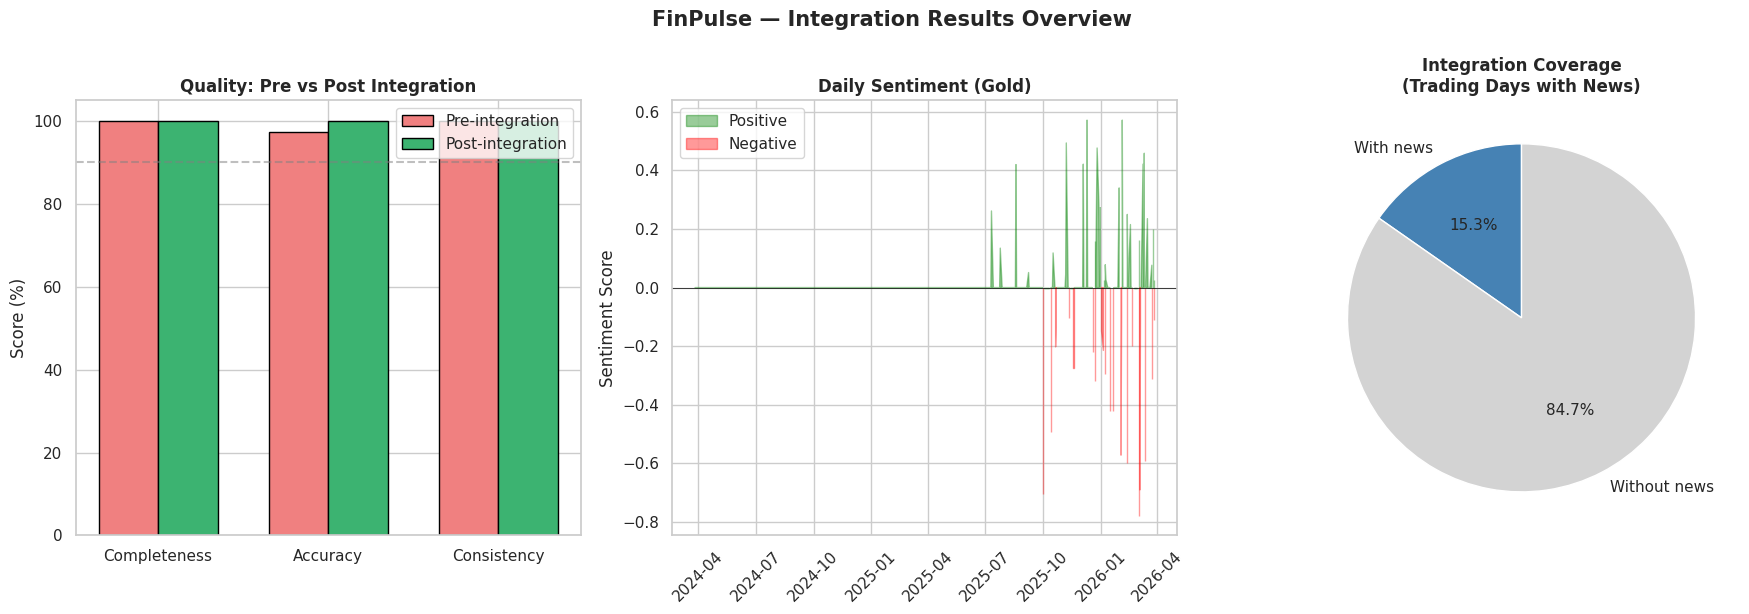

💾 Overview chart saved


In [51]:
# ============================================================
# 10.5 VISUALIZATION — Pre vs Post Quality + Integration Overview
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Chart 1: Quality comparison bar chart ---
dims = ['Completeness', 'Accuracy', 'Consistency']
post_scores = [completeness_post, accuracy_post, consistency_post]

if pre_report:
    pre_scores = [pre_report['prices']['completeness'],
                  pre_report['prices']['accuracy'],
                  pre_report['prices']['consistency']]
    x = np.arange(len(dims))
    w = 0.35
    axes[0].bar(x - w/2, pre_scores, w, label='Pre-integration', color='lightcoral', edgecolor='black')
    axes[0].bar(x + w/2, post_scores, w, label='Post-integration', color='mediumseagreen', edgecolor='black')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(dims)
else:
    axes[0].bar(dims, post_scores, color='mediumseagreen', edgecolor='black')

axes[0].set_ylim(0, 105)
axes[0].set_title('Quality: Pre vs Post Integration', fontweight='bold')
axes[0].set_ylabel('Score (%)')
axes[0].legend()
axes[0].axhline(y=90, color='gray', linestyle='--', alpha=0.5)

# --- Chart 2: Sentiment distribution over time ---
gold_int = df_integrated[df_integrated['asset_name'].str.contains('Gold|gold|GC', case=False, na=False)].copy()
if len(gold_int) > 0:
    gold_int = gold_int.sort_values('date')
    axes[1].fill_between(gold_int['date'], gold_int['sentiment_mean'],
                         where=gold_int['sentiment_mean'] >= 0, alpha=0.4, color='green', label='Positive')
    axes[1].fill_between(gold_int['date'], gold_int['sentiment_mean'],
                         where=gold_int['sentiment_mean'] < 0, alpha=0.4, color='red', label='Negative')
    axes[1].axhline(y=0, color='black', linewidth=0.5)
    axes[1].set_title('Daily Sentiment (Gold)', fontweight='bold')
    axes[1].set_ylabel('Sentiment Score')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[1].tick_params(axis='x', rotation=45)

# --- Chart 3: Integration coverage ---
coverage_data = [
    df_integrated['has_news'].sum(),
    (~df_integrated['has_news']).sum()
]
labels_cov = ['With news', 'Without news']
colors_cov = ['steelblue', 'lightgray']
axes[2].pie(coverage_data, labels=labels_cov, colors=colors_cov, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[2].set_title('Integration Coverage\n(Trading Days with News)', fontweight='bold')

plt.suptitle('FinPulse — Integration Results Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/exports/integration_quality_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Overview chart saved')

---

## 11. Export Integrated Data for Analysis

In [52]:
# ============================================================
# EXPORT FOR DOWNSTREAM ANALYSIS
# ============================================================

# Save the flat integrated DataFrame as CSV for backup/portability
export_cols = [
    'asset_name', 'ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
    'daily_return_pct', 'sma_7', 'sma_21', 'ema_7', 'ema_21',
    'rsi_14', 'bollinger_upper', 'bollinger_lower', 'bollinger_pct',
    'volatility_7', 'volatility_21', 'price_vs_sma21',
    'sentiment_mean', 'sentiment_median', 'sentiment_std',
    'news_count', 'positive_ratio', 'negative_ratio', 'has_news'
]
available_export = [c for c in export_cols if c in df_integrated.columns]

df_export = df_integrated[available_export].copy()
df_export.to_csv('data/processed/integrated_data.csv', index=False)

print(f'💾 Exported integrated data: data/processed/integrated_data.csv')
print(f'   Shape: {df_export.shape[0]} rows × {df_export.shape[1]} columns')
print(f'   Assets: {df_export["asset_name"].unique().tolist()}')

# Also save enriched news with sentiment
news_export_cols = [c for c in df_news.columns if c != 'title_length']  # exclude temp cols
df_news[news_export_cols].to_csv('data/processed/news_with_sentiment.csv', index=False)
print(f'💾 Exported enriched news: data/processed/news_with_sentiment.csv')
print(f'   Shape: {df_news.shape[0]} rows')

💾 Exported integrated data: data/processed/integrated_data.csv
   Shape: 2014 rows × 27 columns
   Assets: ['dxy', 'gold', 'silver', 'sp500']
💾 Exported enriched news: data/processed/news_with_sentiment.csv
   Shape: 156 rows


---

## 12. Summary & Conclusions

### What was done in this notebook

| Step | Description | FAQ |
|------|-------------|-----|
| Schema alignment | Analyzed differences between prices and news datasets | 7 |
| Pre-integration cleaning | Fixed duplicates, nulls, normalized text | 7, 9 |
| Sentiment enrichment | VADER + TextBlob on news headlines, cross-validated | 7 |
| Technical indicators | RSI, SMA, EMA, Bollinger, volatility on prices | 7 |
| Temporal integration | Daily sentiment aggregation + left join with prices | 7 |
| Integration error measurement | Coverage, unmatched records, granularity, schema completeness | 7 |
| MongoDB storage | Nested documents in `integrated_data` collection | 6 |
| Neo4j storage | Graph model with Asset, TradingDay, Sentiment nodes | 6 |
| Queries | 2 MongoDB aggregation + 3 Cypher queries | 6 |
| Post-integration quality | Pre vs post comparison on 3 dimensions | 9 |

### Integration Errors Documented
1. **Coverage gap**: Not all trading days have matching news — filled with neutral values
2. **Temporal granularity**: Intraday news aggregated to daily — some information loss
3. **Unmatched records**: News published on weekends/holidays don't match any trading day
4. **Sentiment method disagreement**: VADER vs TextBlob show partial divergence

### Data Flow Summary
```
MongoDB raw (prices + news)
    → Cleaning → Enrichment (sentiment + technicals)
    → Temporal Join → Integrated dataset
    → MongoDB (integrated_data) + Neo4j (graph)
```

### Next Steps
→ **Notebook 04: Storage & Queries** — Advanced queries, analysis  
→ **Notebook 05: Analysis** — Correlation analysis, RQ answers  
→ **Notebook 06: Trading Signals** — Signal generation for real-world use

In [53]:
# Cleanup
client.close()
if NEO4J_AVAILABLE:
    try:
        # py2neo doesn't need explicit close
        pass
    except:
        pass

print('\n✅ Notebook 03 — Data Integration & Enrichment complete.')
print('\n📊 Collections created/updated in MongoDB:')
print('   • integrated_data     — main integrated dataset')
print('   • integration_errors  — error metrics')
print('   • quality_reports     — post-integration quality scores')
print('\n📊 Neo4j graph:')
print('   • Asset, TradingDay, DailySentiment nodes')
print('   • HAS_TRADING_DAY, HAS_SENTIMENT, NEXT_DAY, CORRELATES_WITH relationships')
print('\n📌 Next: 04_storage_queries.ipynb')


✅ Notebook 03 — Data Integration & Enrichment complete.

📊 Collections created/updated in MongoDB:
   • integrated_data     — main integrated dataset
   • integration_errors  — error metrics
   • quality_reports     — post-integration quality scores

📊 Neo4j graph:
   • Asset, TradingDay, DailySentiment nodes
   • HAS_TRADING_DAY, HAS_SENTIMENT, NEXT_DAY, CORRELATES_WITH relationships

📌 Next: 04_storage_queries.ipynb
